# **Lab 1: KNN**

Explore the data, implement the KNN algorithm and evaluate the results. This is the first lab, please select **6 random digits**, this *ID* is your name for the rest of the course so **please save it to use for other labs and exams**. 

- Submit this notebook to eclass with the name "lab1_123456.ipynb" and replace "123456" by your ID.

In [28]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy.stats import mode
from sklearn import datasets
from sklearn import model_selection
import matplotlib.pyplot as plt

Import the data using `datasets.load_iris()`, check the output of the function. Read the documentation to choose how you want to import the dataset.

In [ ]:
iris_dataset =  datasets.load_iris()
X = iris_dataset['data']
y = iris_dataset['target']
feature_names = ["Sepal length", "Sepal width", "Petal length", "Petal width"]  
class_names   = ["Setosa", "Versicolor", "Virginica"]

## Data Analysis

Check the **shape of X and y** to see if they have they make sense. **Variable y** should contain the labels for datapoints in X, check the labels and how many different labels there are.

In [30]:
print("Number of features: " + f"{len(feature_names)}")
print("Number of samples: "  + f"{X.shape[0]}")
print("Number of classes: "  + f"{len(class_names)}")
print("Labels: " + f"{class_names}")

Number of features: 4
Number of samples: 150
Number of classes: 3
Labels: ['Setosa', 'Versicolor', 'Virginica']


Select two columns of X to plot each datapoint in a 2Dimensional space. Make sure that datapoint of the same class have the same color, and datapoints of different class have different colors (see `scatter()` function from `matplotlib`). Examine visually which pair of features better separate the flowers into the different classes. Add labels to the x and y axis of each plot in the subplot.

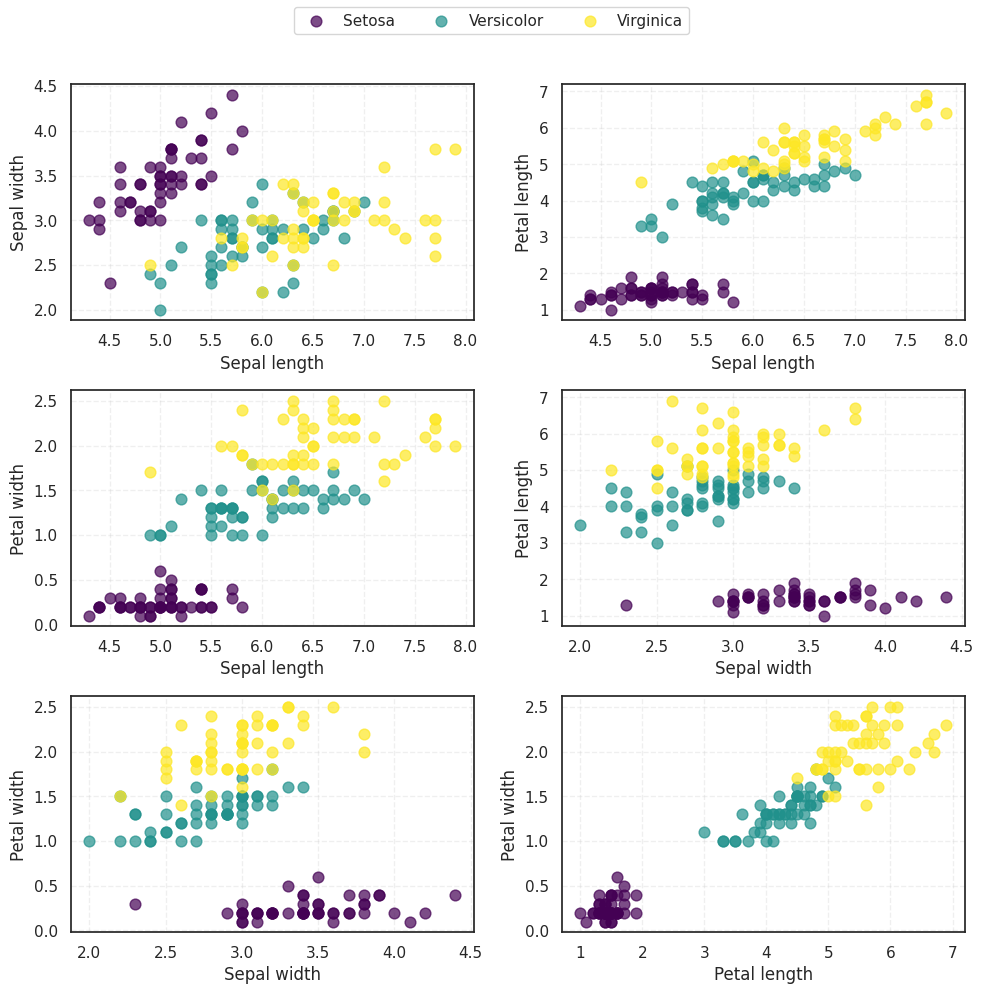

In [31]:
colors = ["#440154", "#21918c", "#fde725"]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

pairs = []
n_features = X.shape[1]

for i in range(n_features):
    for j in range(i + 1, n_features):
        pairs.append((i, j))

for ax, (i, j) in zip(axes.ravel(), pairs):
    for class_id, class_name, color in zip(range(len(class_names)), class_names, colors):
        ax.scatter(
            X[y == class_id, i],
            X[y == class_id, j],
            label=class_name,
            color=color,
            s=60,
            alpha=0.7
        )
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.grid(True, linestyle="--", alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Select a combination of features and use `sns.kdeplot()` to visualize the distribution of the data (probability density function). Condition again the plots on class labels so that each class is represented with a distinct color and ensure that are properly labeled. Evaluate which feature combinations provide better class separability in the density space.

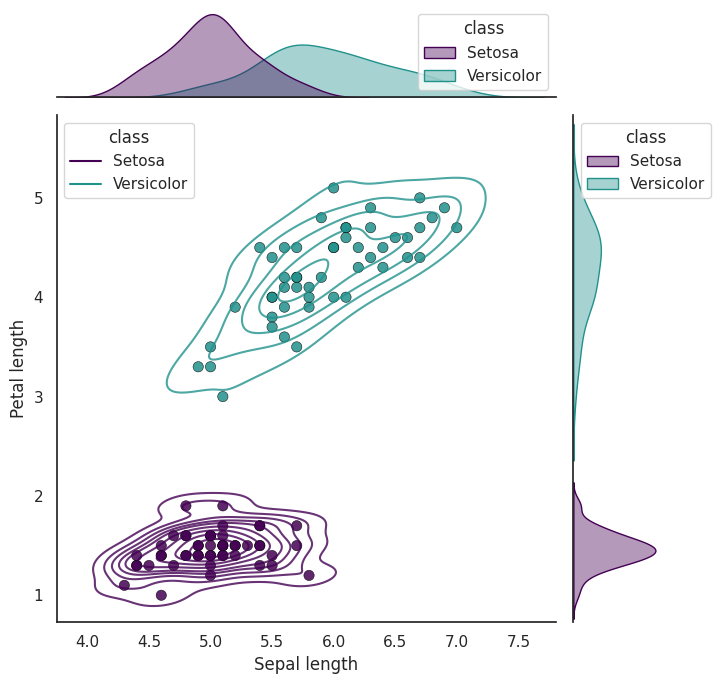

In [32]:
i, j = 0, 2  
mask = (y == 0) | (y == 1)

df = pd.DataFrame({
    "x": X[mask, i],
    "y": X[mask, j],
    "class": [class_names[c] for c in y[mask]]
})

sns.set_theme(style="white", context="notebook")

g = sns.JointGrid(data=df, x="x", y="y", height=7)

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="class",
    palette=colors[:2],
    s=55,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4,
    ax=g.ax_joint
)

sns.kdeplot(
    data=df,
    x="x",
    y="y",
    hue="class",
    palette=colors[:2],
    fill=False,
    alpha=0.8,
    ax=g.ax_joint
)

sns.kdeplot(
    data=df,
    x="x",
    hue="class",
    palette=colors[:2],
    fill=True,
    alpha=0.4,
    ax=g.ax_marg_x
)

sns.kdeplot(
    data=df,
    y="y",
    hue="class",
    palette=colors[:2],
    fill=True,
    alpha=0.4,
    ax=g.ax_marg_y
)

g.ax_joint.set_xlabel(feature_names[i])
g.ax_joint.set_ylabel(feature_names[j])

plt.show()

## Training 

Create a function to predict the class of a set of points given a **training set** using KNN. (check function `mode` from `scipy.stats`)

In [33]:
def euclian_distance(xTrain, xTest):
    return np.sqrt(np.sum((xTrain - xTest) ** 2, axis=1))

def KNN(Xtrain, ytrain, Xtest, K):
    predictions = []

    for x_test in Xtest:
        distances = euclian_distance(Xtrain, x_test)
        nearest_idx = np.argsort(distances)[:K]
        nearest_labels = ytrain[nearest_idx]

        pred_class = mode(nearest_labels, keepdims=True).mode[0]
        predictions.append(pred_class)

    return np.array(predictions)


Test your function! Make sure that you test with datapoints that are not in **Xtrain**

In [34]:
X_new = np.array([
    [5.9, 3.1, 4.2, 1.3],
    [6.7, 2.8, 5.8, 2.2],
    [4.8, 3.4, 1.6, 0.3],
    [5.5, 2.5, 3.7, 1.0],
    [6.2, 3.0, 5.0, 1.8]
])

pred = KNN(X, y, X_new, K=10)
print("Predictions")
print(pred)

Predictions
[1 2 0 1 2]


Divide your dataset into training and testing set. Given the simplicity of this dataset, set a 30:35:35 distribution for the dataset (see `model_selection.train_test_split()` function you imported previously). Use `random_state=1` for reproducibility. 

In [35]:
Xtrain, aux1, ytrain, aux2 = model_selection.train_test_split(
    X, y, test_size=0.70, random_state=1, stratify=y
)

Xtest, Xval, ytest, yval = model_selection.train_test_split(
    aux1, aux2, test_size=0.50, random_state=1, stratify=aux2
)

print("==================================================")
print("Dimensions of data")
print("Xtrain.shape: ", Xtrain.shape, ", 30%")
print("ytrain.shape: ", ytrain.shape, ", 30%")
print("Xval.shape: ", Xval.shape, ", 35%")
print("yval.shape: ", yval.shape, ", 35%")
print("Xtest.shape: ", Xtest.shape, ", 35%")
print("ytest.shape: ", ytest.shape, ", 35%")
print("==================================================")

Dimensions of data
Xtrain.shape:  (45, 4) , 30%
ytrain.shape:  (45,) , 30%
Xval.shape:  (53, 4) , 35%
yval.shape:  (53,) , 35%
Xtest.shape:  (52, 4) , 35%
ytest.shape:  (52,) , 35%


Create a function to compute the **overall accuracy**, and the **accuracy per class** of the predictions

In [36]:
def accuracy(pred, target):
    overall_acc = np.mean(pred == target)

    acc_class_0 = np.mean(pred[target == 0] == target[target == 0])
    acc_class_1 = np.mean(pred[target == 1] == target[target == 1])
    acc_class_2 = np.mean(pred[target == 2] == target[target == 2])

    return overall_acc, acc_class_0, acc_class_1, acc_class_2

Use your train set to define **K** in a range of 1 to 20 by observing the **overall accuracy** and print your best K and best validation accuracy.

In [37]:
accs = []
ks = range(1, 21)
best_k = -1
best_total_acc = -1

for k in ks:
    pred = KNN(Xtrain, ytrain, Xval, k)
    total_acc, _, _, _ = accuracy(pred, yval)
    accs.append(total_acc)

    if total_acc > best_total_acc:
        best_total_acc = total_acc
        best_k = k

print(f"Best k: {best_k}, with accuracy: {best_total_acc:.4f}")

Best k: 1, with accuracy: 0.9811


Make a barplot to compare the overall accuracy for different Ks highligthing the best value of K

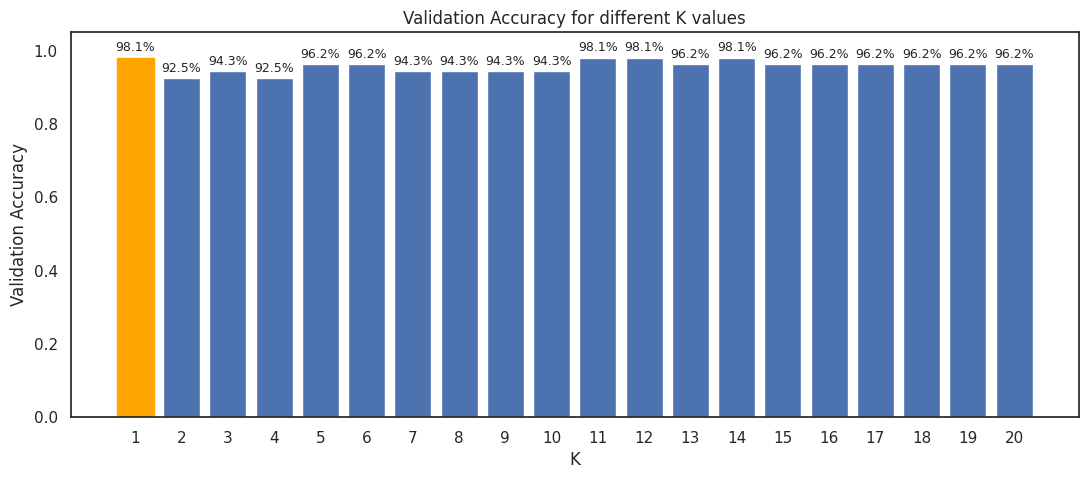

In [38]:
plt.figure(figsize=(13, 5))
bars = plt.bar(ks, accs)

bars[best_k - 1].set_color("orange")
for bar, acc in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("K")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for different K values")
plt.xticks(ks)
plt.ylim(0, 1.05)

plt.show()

Joint the train set with validation, to predict for the test set. Use a bar plot to show the **overall accuraccy** an the **accuracy per class**.

Shape of Xtrain2: (98, 4)
Shape of ytrain2: (98,)
Overall accuracy on the test set: 0.9423076923076923, with K = 1
Class 0 accuracy:  1.0
Class 1 accuracy:  0.8823529411764706
Class 2 accuracy:  0.9411764705882353


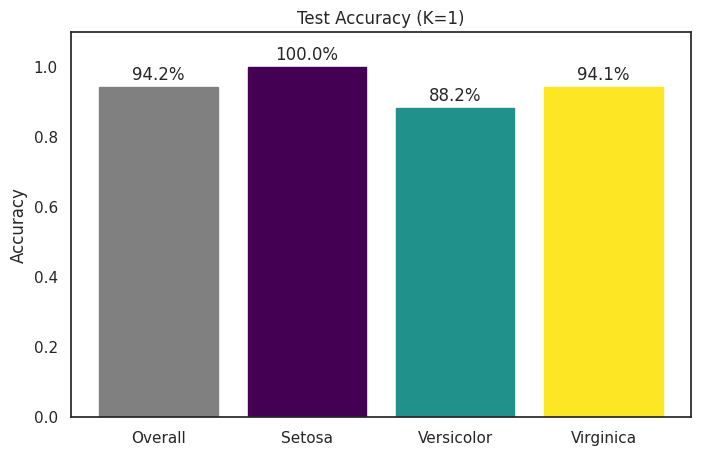

In [39]:
Xtrain2 = np.concatenate((Xtrain, Xval), axis=0)
ytrain2 = np.concatenate((ytrain, yval), axis=0)
ypred = KNN(Xtrain2, ytrain2, Xtest, best_k)

total_acc, acc_0, acc_1, acc_2 = accuracy(ypred, ytest)

print("Shape of Xtrain2:", Xtrain2.shape) 
print("Shape of ytrain2:", ytrain2.shape)
print(f"Overall accuracy on the test set: {total_acc}, with K = {best_k}")
print("Class 0 accuracy: ", acc_0)
print("Class 1 accuracy: ", acc_1)
print("Class 2 accuracy: ", acc_2)

labels = ["Overall", "Setosa", "Versicolor", "Virginica"]
values = [total_acc, acc_0, acc_1, acc_2]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

bars[0].set_color("gray")
bars[1].set_color("#440154")
bars[2].set_color("#21918c")
bars[3].set_color("#fde725")

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val*100:.1f}%",
        ha='center',
        va='bottom'
    )

plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title(f"Test Accuracy (K={best_k})")

plt.show()

Plot the training points using circles and using different colors for different classes. Plot the test points using stars, use different colors for different predicted classes. Add legend, title and labels for the x and y axis. You chose which features to use for the 2D plot.

/tmp/ipykernel_126284/1380654304.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(classes))


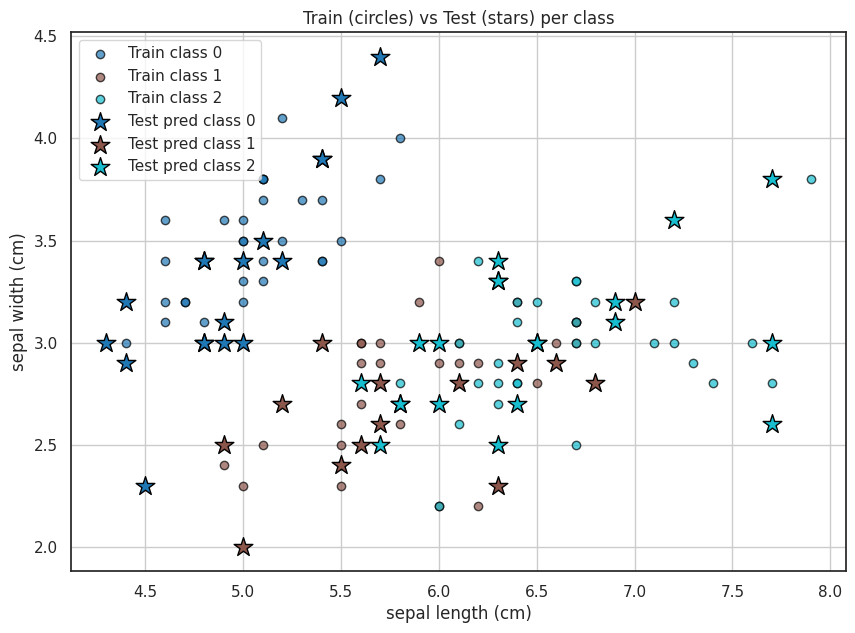

In [ ]:
# Example for Setosa vs Versicolor using "Sepal length" and "Sepal width" to get the same result as the one above. 
# i, j = 0, 2

# colors = ["#440154", "#21918c", "#fde725"]  
# plt.figure(figsize=(7, 6))
#  Your code here:

axis = [0, 1]
classes = [0,1,2]
colors = plt.cm.get_cmap('tab10', len(classes))
plt.figure(figsize=(10, 7))

for class_id in classes:
    idx = (ytrain2 == class_id)
    plt.scatter(
        Xtrain2[idx, axis[0]],
        Xtrain2[idx, axis[1]],
        c=[colors(class_id)],
        label=f'Train class {class_id}',
        marker='o',
        edgecolors='black',
        alpha=0.7
    )

for class_id in classes:
    idx = (ypred == class_id)
    plt.scatter(
        Xtest[idx, axis[0]],
        Xtest[idx, axis[1]],
        c=[colors(class_id)],
        label=f'Test pred class {class_id}',
        marker='*',
        s=200,
        edgecolors='black'
    )
plt.title('Train (circles) vs Test (stars) per class')
plt.xlabel(f'{iris_dataset.feature_names[axis[0]]}')
plt.ylabel(f'{iris_dataset.feature_names[axis[1]]}')
plt.legend()
plt.grid(True)
plt.show()

Check your results of K and accuracy using `KNeighborsClassifier` from `sklearn`.

In [41]:
from sklearn.neighbors import KNeighborsClassifier

K = np.arange(1, 21)
accuracy_sklearn = []

bestK_sklearn = None
best_acc = -1

for k in K:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtrain, ytrain)
    pred_val = model.predict(Xval)
    acc = np.mean(pred_val == yval)
    accuracy_sklearn.append(acc)
    
    if acc > best_acc:
        best_acc = acc
        bestK_sklearn = k

accuracy_sklearn = np.array(accuracy_sklearn)

print("Best K with sklearn:", bestK_sklearn)
print("Best validation accuracy with sklearn:", accuracy_sklearn.max())

Best K with sklearn: 1
Best validation accuracy with sklearn: 0.9811320754716981


## Questions for think

Consider the KNN algorithm with `K=3`. Suppose that, for a given test point, its three nearest neighbors belong to three different classes (one sample from each class). 

- What issue arises in this situation for the KNN decision rule? 

- And how is the final class assigned in this implementation, given that we uses the `mode()` function from scipy.stats?”

### KNN with K = 3 and Tie Case

#### 1. What issue arises?

When `K = 3` and the three nearest neighbors belong to different classes (one from each class), a **tie** occurs.  

Each class has the same frequency (1), so the `KNN` decision rule based on majority voting **cannot determine a clear winner**.  

This creates an **ambiguity problem**, since no class has a higher vote than the others.


#### 2. How is the final class assigned in this implementation?

In this implementation, the function `mode()` from `scipy.stats` is used to select the predicted class.

When there is a tie, `mode()` resolves it by returning the **smallest value among the tied classes**.

For example:

- Nearest neighbors: `[0, 1, 2]`
- All classes appear once → tie
- `mode()` returns: `0`

Therefore, the final predicted class will be the one with the **lowest numerical label**.


#### 3. Important note

This tie-breaking strategy introduces a **bias**, since the decision depends on how classes are numerically encoded rather than on the actual data distribution.